# Tutorial 2 — Chaotic competition, a regime shift, and the control window

The first tutorial used a small hand-checkable example. This one applies `epscontrol` to a system with a real ecological counterpart, under the observational constraint that actually holds in the field: **only one species is counted**.

## The system

Four species compete for shared resources. Their abundances follow the competitive Lotka–Volterra equations

$$\dot{x}_i = r_i\, x_i \Bigl( 1 - \sum_{j} A_{ij} x_j \Bigr), \qquad i = 1, \dots, 4,$$

with the growth rates $r$ and interaction matrix $A$ of Vano, Wildenberg, Anderson, Noel & Sprott, *Chaos in low-dimensional Lotka–Volterra models of competition*, Nonlinearity **19** (2006), 2391. This is one of the lowest-dimensional competition systems known to be chaotic: its largest Lyapunov exponent is about $0.02$, so the four populations cycle irregularly and forever, and two nearly identical communities drift apart.

At time $t = 500$ the environment changes — a **press disturbance** in ecological terms, such as sustained warming, nutrient loading or a habitat modification that persists. The interaction matrix switches to a regime where species 1 is niche-differentiated from each competitor while species 2, 3 and 4 exclude one another. The new system is **bistable**: the communities $\{1,2\}$ and $\{1,3\}$ are both stable against invasion, and species 1 settles at a **high** abundance $0.714$ in the first and a **low** abundance $0.294$ in the second.

Which one a community ends up in is decided by *where the chaotic phase happened to have carried it* when the disturbance struck. This is a **priority effect**, and it is why the outcome looks stochastic even though the dynamics are deterministic.

## The observation

We monitor **species 1 only**, every 5 time units — one census of one taxon, the usual situation in a monitoring programme. The unobserved species are reconstructed by delay-coordinate embedding, so a state is the recent history $(x_1(t), x_1(t-5), x_1(t-10))$.

## The question

The evaluation is the **terminal shortfall** of species 1, $h = 1 - x_1(\infty)$, defined only at the end of each record — small $h$ means species 1 ended abundant. Standing at some moment during the chaos, with only the species-1 record in hand:

* could a small intervention still secure the good outcome, and how small?
* when does that stop being true?

That is exactly $h_f^{\varepsilon\text{-}\ell^p}$ and the sublevel controllability value $C^{\ell^p}_{h,f}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import epscontrol as ec

rng = np.random.default_rng(0)
print("epscontrol", ec.__version__)

epscontrol 0.2.0


## 1. The chaotic attractor

First, the undisturbed system. `simulate_competition` integrates the equations with a fourth-order Runge–Kutta step; passing no `t_switch` leaves the dynamics fixed.

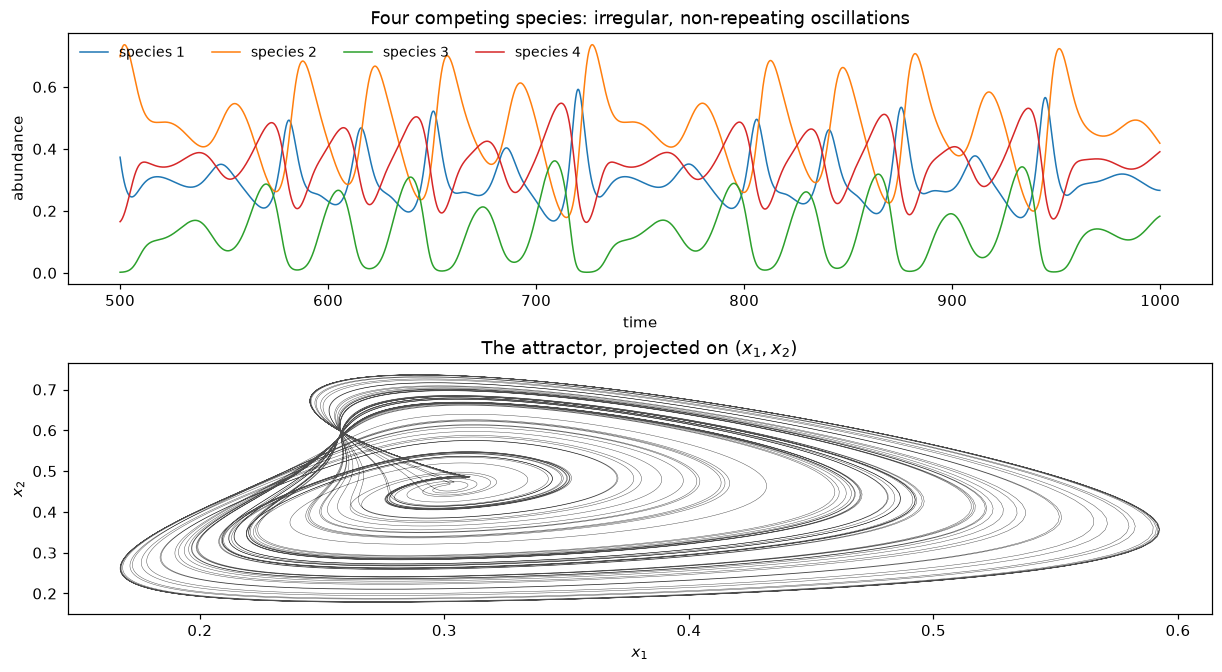

In [2]:
traj, times = ec.datasets.simulate_competition(
    np.array([0.3, 0.3, 0.3, 0.3]), t_max=3000.0, sample_every=0.2
)
traj = traj[2500:]           # discard the approach to the attractor
times = times[2500:]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True,
                         gridspec_kw={"height_ratios": [1, 1]})
for i in range(4):
    axes[0].plot(times[:2500], traj[:2500, i], lw=1.0, label=f"species {i+1}")
axes[0].set_xlabel("time"); axes[0].set_ylabel("abundance")
axes[0].legend(ncol=4, frameon=False, fontsize=9)
axes[0].set_title("Four competing species: irregular, non-repeating oscillations")

axes[1].plot(traj[:, 0], traj[:, 1], lw=0.3, color="0.3")
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
axes[1].set_title("The attractor, projected on $(x_1, x_2)$")
fig.savefig("eco_fig_attractor.png", dpi=140, bbox_inches="tight")

The oscillations never repeat. To confirm this is chaos rather than a long cycle, we compute the largest Lyapunov exponent by evolving a tangent vector alongside the orbit and accumulating its stretching rate. A positive value means nearby trajectories separate exponentially.

In [3]:
A = ec.datasets.competition_matrix
r = ec.datasets.competition_growth_rates

def largest_lyapunov(A, r, x0, dt=0.01, n=400_000, n_skip=50_000):
    x, v, total, count = x0.copy(), np.eye(4)[0], 0.0, 0
    for i in range(n):
        J = r[:, None] * (np.eye(4) * (1.0 - A @ x)[:, None] - np.outer(x, np.ones(4)) * A)
        v = v + dt * (J @ v)
        x = ec.datasets._lv_step(x, A, r, dt)
        nv = np.linalg.norm(v)
        if nv > 0:
            v /= nv
            if i >= n_skip:
                total += np.log(nv); count += 1
    return total / (count * dt)

lam = largest_lyapunov(A, r, np.array([0.3, 0.3, 0.3, 0.3]))
print(f"largest Lyapunov exponent: {lam:.4f}   (published value ~0.0203)")
print(f"error-doubling time: {np.log(2)/lam:.0f} time units")

largest Lyapunov exponent: 0.0201   (published value ~0.0203)
error-doubling time: 34 time units


Positive, and matching the published value. The doubling time tells us how fast an observational error grows — after about 35 time units it has doubled, after 350 it has grown by a factor of $2^{10} \approx 1000$. This is the practical horizon of prediction for this community.

## 2. The regime shift and the two possible fates

Now the disturbance. At $t = 500$ the interaction matrix switches. Let us first check the claim that the post-shift system is bistable, by solving for the equilibrium of each candidate pair and testing whether the missing species can invade it.

In [4]:
A_post = ec.datasets.competition_matrix_post

rows = []
for j in (1, 2, 3):
    idx = np.array([0, j])
    xs = np.linalg.solve(A_post[np.ix_(idx, idx)], np.ones(2))
    x = np.zeros(4); x[idx] = xs
    J = r[:, None] * (np.eye(4) * (1.0 - A_post @ x)[:, None] - np.outer(x, np.ones(4)) * A_post)
    ev = np.linalg.eigvals(J).real
    rows.append({"pair": f"{{1,{j+1}}}", "x1*": xs[0], f"partner*": xs[1],
                 "max eigenvalue": ev.max(), "stable": ev.max() < 1e-9})
pd.DataFrame(rows).set_index("pair").round(4)

,x1*,partner*,max eigenvalue,stable
pair,,,,
"{1,2}",0.7143,0.5714,-0.0874,True
"{1,3}",0.2941,0.8824,-0.1850,True
"{1,4}",0.9589,0.1370,0.6497,False


Two of the three pairs are stable against invasion by the species left out: $\{1,2\}$ with species 1 at $0.714$, and $\{1,3\}$ with species 1 at $0.294$. The community will end in one or the other — a factor of 2.4 difference in the abundance of the species we care about, decided by chaos.

Two communities that differ by less than the width of a census error illustrate the point:

final x1:  A = 0.2941   B = 0.7143


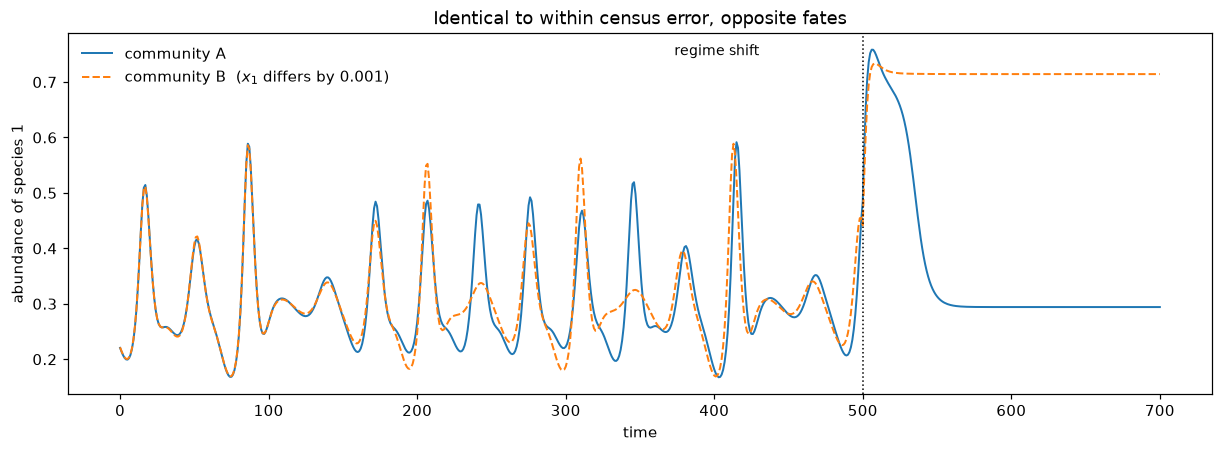

In [5]:
# A state on the attractor from which a 0.001 difference flips the fate.
# Such states are common: they are the ones lying near a basin boundary
# of the post-shift system, and chaos visits that neighbourhood constantly.
x_a = traj[10144].copy()
x_b = x_a + np.array([1e-3, 0.0, 0.0, 0.0])     # differs by 0.001 in species 1

pair, tt = ec.datasets.simulate_competition(
    np.stack([x_a, x_b]), t_switch=500.0, t_max=700.0, sample_every=1.0
)

fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
ax.plot(tt, pair[:, 0, 0], lw=1.3, label="community A")
ax.plot(tt, pair[:, 1, 0], lw=1.3, ls="--", label="community B  ($x_1$ differs by 0.001)")
ax.axvline(500.0, color="k", lw=1.0, ls=":")
ax.annotate("regime shift", xy=(500, ax.get_ylim()[1]*0.95), xytext=(430, ax.get_ylim()[1]*0.95),
            fontsize=9, ha="right")
ax.set_xlabel("time"); ax.set_ylabel("abundance of species 1")
ax.set_title("Identical to within census error, opposite fates")
ax.legend(frameon=False)
fig.savefig("eco_fig_divergence.png", dpi=140, bbox_inches="tight")

print(f"final x1:  A = {pair[-1,0,0]:.4f}   B = {pair[-1,1,0]:.4f}")

The two records are visually indistinguishable for hundreds of time units, then separate and settle on different plateaus. No amount of measurement precision removes this — it only postpones the divergence, by a time proportional to the logarithm of the precision.

## 3. The ensemble, observed through one species

Since single trajectories cannot be predicted, we run an **ensemble** — the standard response to chaos in weather and climate forecasting. Members are states sampled along the attractor with observational noise added.

`chaotic_competition` assembles this and applies the observational constraint: species 1 only, every 5 time units, delay-embedded into 3 dimensions.

In [6]:
adata = ec.datasets.chaotic_competition(
    n_members=60, t_switch=500.0, t_max=700.0,
    obs_interval=5.0, embedding_dim=3, embedding_lag=1, seed=20260807,
)
info = adata.uns["competition"]

print(adata)
print(f"\n{adata.n_obs} states = {60} members x {adata.n_obs//60} observation times")
print("observed:  species", info["observed_species"] + 1, f"every {info['obs_interval']:g} time units")
print("state    = ", list(adata.var_names))
print("h levels = ", np.unique(adata.obs['h'].dropna()).round(4))

AnnData object with n_obs × n_vars = 8340 × 3
    obs: 'seq_id', 'time', 'h', 't', 'phase'
    uns: 'cost_matrix', 'competition'
    layers: None (.X)

8340 states = 60 members x 139 observation times
observed:  species 1 every 5 time units
state    =  ['x1(t-0)', 'x1(t-5)', 'x1(t-10)']
h levels =  [0.2857 0.7059]


The state is a delay vector of the species-1 record, not the true four-species state. The evaluation $h$ takes exactly two values, one per alternative stable state, and is defined only at the end of each record.

Let us look at the ensemble as an observer would see it, and at the true system underneath for comparison.

18/60 members end with species 1 abundant, 42/60 scarce


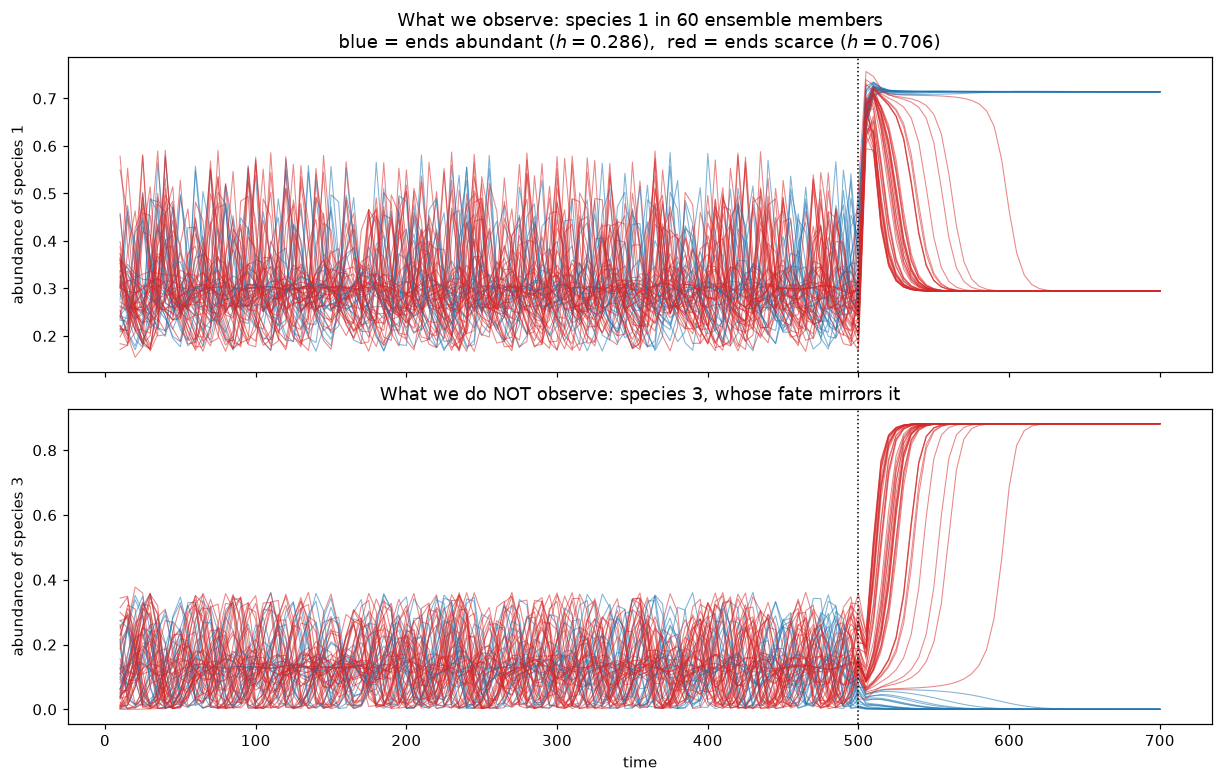

In [7]:
truth, t_emb = info["true_states"], info["times"]
h = adata.obs["h"].to_numpy().reshape(60, -1)
fate = np.nanmax(h, axis=1)
good = fate < fate.max()          # ends in the {1,2} state: species 1 abundant

fig, axes = plt.subplots(2, 1, figsize=(11, 7), constrained_layout=True, sharex=True)
for m in range(60):
    c = "tab:blue" if good[m] else "tab:red"
    axes[0].plot(t_emb, truth[m, :, 0], color=c, lw=0.7, alpha=0.55)
axes[0].axvline(500.0, color="k", lw=1.0, ls=":")
axes[0].set_ylabel("abundance of species 1")
axes[0].set_title("What we observe: species 1 in 60 ensemble members\n"
                  "blue = ends abundant ($h=0.286$),  red = ends scarce ($h=0.706$)")

for m in range(60):
    c = "tab:blue" if good[m] else "tab:red"
    axes[1].plot(t_emb, truth[m, :, 2], color=c, lw=0.7, alpha=0.55)
axes[1].axvline(500.0, color="k", lw=1.0, ls=":")
axes[1].set_xlabel("time"); axes[1].set_ylabel("abundance of species 3")
axes[1].set_title("What we do NOT observe: species 3, whose fate mirrors it")
fig.savefig("eco_fig_ensemble.png", dpi=140, bbox_inches="tight")

print(f"{good.sum()}/60 members end with species 1 abundant, {(~good).sum()}/60 scarce")

Before the shift the two colours are completely interleaved — the eventual fate is not visible in the trace. After it they separate onto two plateaus. **The information was there all along**, encoded in which part of the attractor each member occupied, but it is not readable by eye.

## 4. The control effect function

Now the library's question. Build the problem: states are the delay vectors, the dynamics are the shift along each record, and the cost of a control input is the distance moved in the reconstructed state space.

In [8]:
prob = ec.build_problem(adata, p=np.inf)

print("hypotheses:", ec.check_hypotheses(adata, problem=prob))
print("solver:", prob.solver, " | h levels:", prob.levels.round(4))

hypotheses: {'disjoint_domains': True, 'covers_X': True, 'preimage_decomposition': True, 'dom_h_fixed': True}
solver: layered  | h levels: [0.2857 0.7059]


All four structural hypotheses hold. The dataset ships a cost matrix that forbids two things: jumps between different observation times (you cannot intervene in the past), and jumps out of a terminal state (once the community has settled and been assessed, the outcome is history). The latter is what makes $\operatorname{dom} h$ consist of $(c,\varepsilon)$-fixed points, the hypothesis of Theorem 3.12.

With $p = \infty$ each individual intervention is capped at $\varepsilon$, but one may intervene at every census — a management programme with a bounded per-visit effort.

In [9]:
budgets = [0.0, 0.005, 0.01, 0.02, 0.05, 0.2]
ec.control_effect(adata, budgets, problem=prob)

t = adata.obs["t"].to_numpy()
best = prob.levels[0]
windows = [(0, 200), (200, 400), (400, 500), (500, 560), (560, 700)]

tab = []
for eps in budgets:
    eff = adata.obs[ec.result_key(eps, np.inf)].to_numpy()
    row = {"eps": eps}
    for lo, hi in windows:
        m = (t >= lo) & (t < hi)
        row[f"{lo}-{hi}"] = np.isclose(eff[m], best).mean()
    tab.append(row)
print("Fraction of states from which the GOOD outcome is still reachable:\n")
pd.DataFrame(tab).set_index("eps").round(3)

Fraction of states from which the GOOD outcome is still reachable:



,0-200,200-400,400-500,500-560,560-700
eps,,,,,
0.000,0.300,0.300,0.300,0.300,0.300
0.005,0.647,0.473,0.383,0.335,0.300
0.010,1.000,0.931,0.642,0.379,0.301
0.020,1.000,1.000,0.875,0.440,0.302
0.050,1.000,1.000,1.000,0.522,0.304
0.200,1.000,1.000,1.000,0.657,0.305


Read down the $\varepsilon = 0.01$ row. Early in the chaotic phase a budget of $0.01$ secures the good outcome from essentially every state. Approaching the shift it works from about half. Once the shift has passed it is worthless — the same budget that was decisive at $t=100$ changes nothing at $t=600$.

The sublevel controllability value $C^{\ell^\infty}_{h,f}(x, r)$ puts a number on this: the **cheapest intervention** that secures an outcome at least as good as $r$.

states already safe: 30%;  reachable at a price: 69%
  t in [  0,200): median cost 0.0050
  t in [200,400): median cost 0.0072
  t in [400,500): median cost 0.0104
  t in [500,560): median cost 0.1812
  t in [560,700): median cost 0.7227

cost multiplies by 143x from the early chaotic phase to after the shift


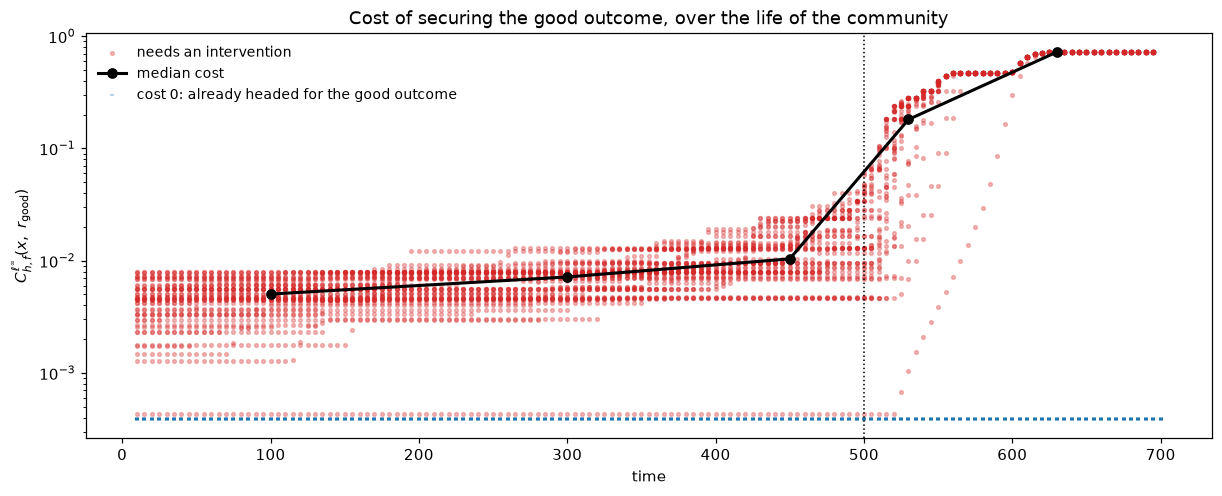

In [10]:
cost_good = prob.control_cost()[:, 0]        # cheapest control securing h <= best
free = cost_good <= 0                        # already headed for the good outcome
paid = np.isfinite(cost_good) & ~free

fig, ax = plt.subplots(figsize=(11, 4.4), constrained_layout=True)
ax.scatter(t[paid], cost_good[paid], s=6, alpha=0.3, color="tab:red",
           label="needs an intervention")
med = [np.median(cost_good[(t >= lo) & (t < hi) & paid]) for lo, hi in windows]
ax.plot([np.mean(w) for w in windows], med, "k-o", lw=2, ms=6, label="median cost")
ax.axvline(500.0, color="k", lw=1.0, ls=":")
ax.set_yscale("log")
ymin = ax.get_ylim()[0]
ax.scatter(t[free], np.full(free.sum(), ymin * 1.3), s=6, alpha=0.3, color="tab:blue",
           marker="_", label="cost 0: already headed for the good outcome")
ax.set_xlabel("time"); ax.set_ylabel(r"$C^{\ell^\infty}_{h,f}(x,\ r_{\mathrm{good}})$")
ax.set_title("Cost of securing the good outcome, over the life of the community")
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.savefig("eco_fig_cost.png", dpi=140, bbox_inches="tight")

print(f"states already safe: {free.mean():.0%};  reachable at a price: {paid.mean():.0%}")
for (lo, hi), mm in zip(windows, med):
    print(f"  t in [{lo:3d},{hi:3d}): median cost {mm:.4f}")
print(f"\ncost multiplies by {med[-1]/med[0]:.0f}x from the early chaotic phase to after the shift")

This is the **control window**, and quantifying it is the practical payoff. Intervention is cheap while the system is still wandering chaotically, becomes steadily more expensive as the disturbance approaches, and is effectively impossible afterwards — a hundredfold rise, computed from a single scalar time series.

Note that the curve rises *before* $t=500$. The window closes while the dynamics still look unchanged, which is the uncomfortable part: by the time a regime shift is visible in the data, the affordable options have already gone.

## 5. Where the leverage is: the difference effect function

The cost tells us what an intervention buys in absolute terms; the difference effect function

$$h_f^{\Delta\varepsilon\text{-}\ell^p} = h_f^{\varepsilon\text{-}\ell^p} - h_f^{0\text{-}\ell^p} \le 0$$

isolates the **gain over doing nothing**. States already headed for the good outcome score zero regardless of budget; the leverage is where a small effort changes the destination.

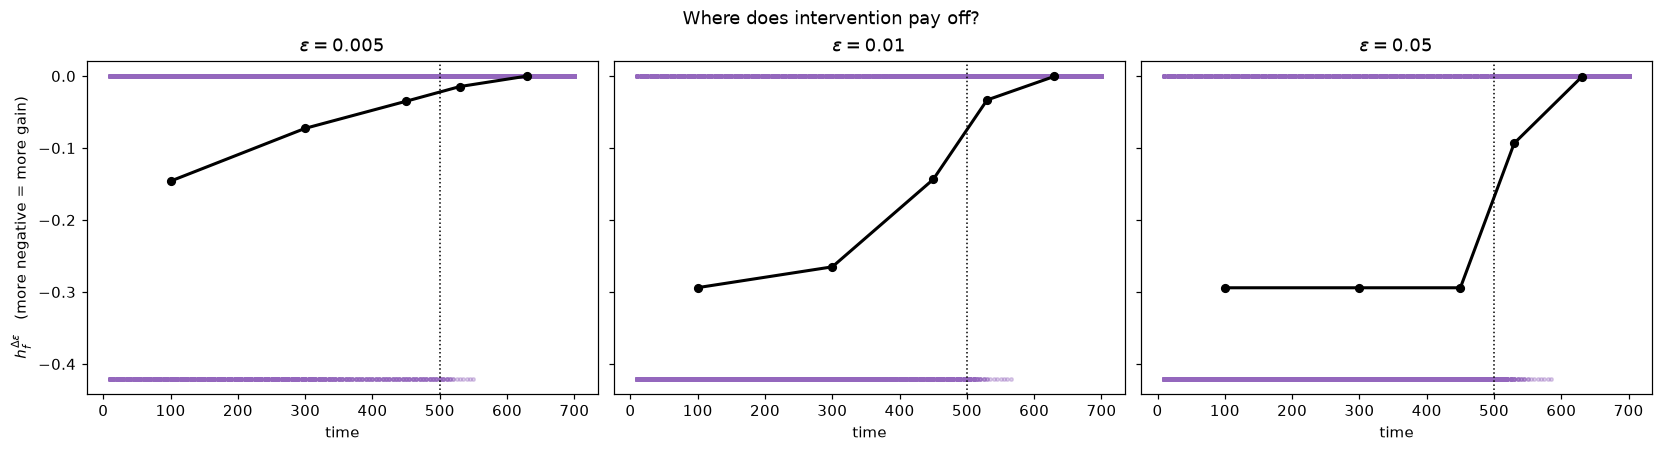

In [11]:
ec.effect_difference(adata, [0.005, 0.01, 0.05], problem=prob)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True, sharey=True)
for ax_, eps in zip(axes, [0.005, 0.01, 0.05]):
    g = adata.obs[ec.result_key(eps, np.inf, prefix="effect_difference")].to_numpy()
    ax_.scatter(t, g, s=5, alpha=0.3, color="tab:purple")
    prof = [np.mean(g[(t >= lo) & (t < hi)]) for lo, hi in windows]
    ax_.plot([np.mean(w) for w in windows], prof, "k-o", lw=2, ms=5)
    ax_.axvline(500.0, color="k", lw=1.0, ls=":")
    ax_.set_xlabel("time"); ax_.set_title(rf"$\varepsilon={eps:g}$")
axes[0].set_ylabel(r"$h_f^{\Delta\varepsilon}$   (more negative = more gain)")
fig.suptitle("Where does intervention pay off?")
fig.savefig("eco_fig_gain.png", dpi=140, bbox_inches="tight")

## 6. What the intervention actually is

`minimizing_path` returns the schedule realizing the optimum: at which censuses to act, and how hard. Take a member that, left alone, ends with species 1 scarce.

In [12]:
eff0 = prob.control_effect(0.0)
doomed = np.nonzero(~np.isclose(eff0, best) & (t < 150))[0]
x_star = int(doomed[0])

print(f"state {x_star}: t = {t[x_star]:.0f}, member {adata.obs['seq_id'].iloc[x_star]}")
print(f"  without control, this community ends at h = {eff0[x_star]:.4f} (species 1 scarce)\n")

for eps in (0.005, 0.01, 0.05):
    p_ = ec.minimizing_path(adata, x_star, eps, problem=prob)
    acts = [(float(t[p_["states"][k]]), float(c)) for k, c in enumerate(p_["costs"]) if c > 1e-9]
    print(f"eps={eps:<6g} -> h = {p_['value']:.4f}   "
          f"{len(acts)} intervention(s), largest {max((a[1] for a in acts), default=0.0):.4f}")
    for tm, c in acts[:4]:
        print(f"     act at t={tm:6.0f}, magnitude {c:.4f}")

state 0: t = 10, member 0
  without control, this community ends at h = 0.7059 (species 1 scarce)

eps=0.005  -> h = 0.7059   0 intervention(s), largest 0.0000
eps=0.01   -> h = 0.2857   2 intervention(s), largest 0.0050
     act at t=   195, magnitude 0.0050
     act at t=   520, magnitude 0.0004
eps=0.05   -> h = 0.2857   2 intervention(s), largest 0.0050
     act at t=   195, magnitude 0.0050
     act at t=   520, magnitude 0.0004


Two nudges of a few thousandths — a fraction of a percent of carrying capacity, applied at two censuses out of 139 — redirect the community to the other stable state. That is the leverage chaos provides: it is precisely *because* the system amplifies small differences that small interventions work, provided they are made early enough.

The same calculation late in the record returns interventions orders of magnitude larger, which is the honest answer that the outcome is no longer worth buying.

## 7. The three-parameter filtration

Finally, the persistence view. Sweeping $(p, \varepsilon, \delta)$ — accounting of effort, size of effort, quality demanded — gives a filtration whose members are the states that can still achieve $\delta$.

nested in delta and eps: True | nested in p: True


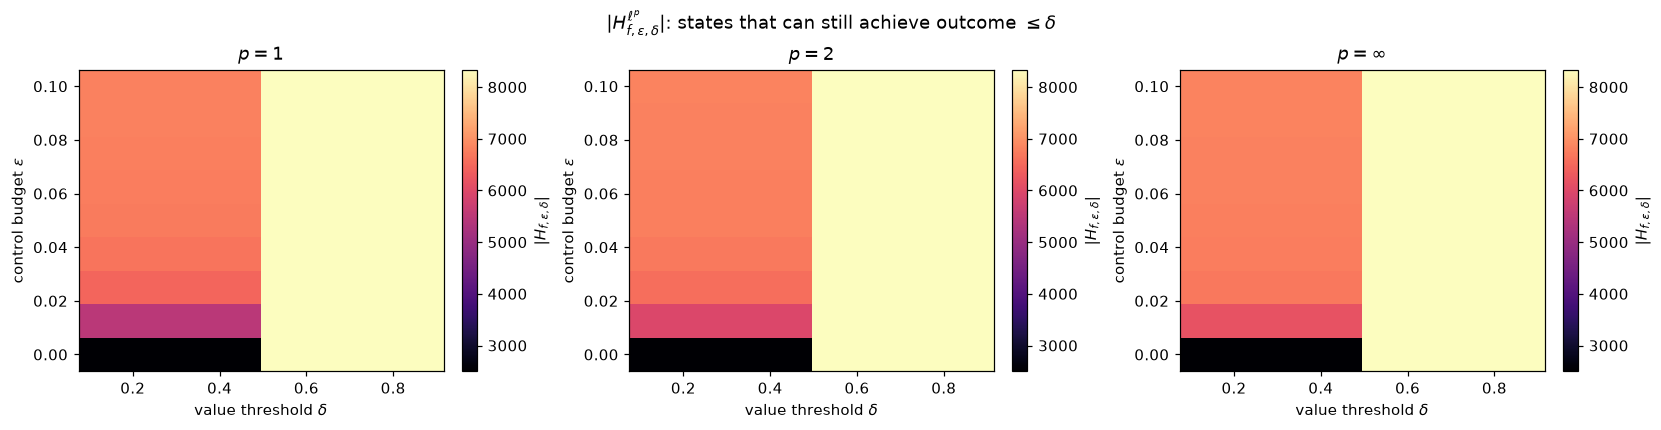

In [13]:
filt = ec.filtration(prob, ps=(1.0, 2.0, np.inf),
                     epsilons=np.linspace(0.0, 0.1, 9), kind="value")
print("nested in delta and eps:", filt.is_filtration(),
      "| nested in p:", filt.is_filtration_in_p())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), constrained_layout=True)
for i in range(3):
    ec.plot_filtration_sizes(filt, p_index=i, ax=axes[i])
fig.suptitle(r"$|H^{\ell^p}_{f,\varepsilon,\delta}|$: states that can still achieve outcome $\leq\delta$")
fig.savefig("eco_fig_filtration.png", dpi=140, bbox_inches="tight")

In [14]:
sizes = filt.sizes[-1]            # p = inf slice
pd.DataFrame(sizes / prob.n,
             index=[f"eps={e:.3f}" for e in filt.epsilons],
             columns=[f"delta={d:.3f}" for d in filt.deltas]).round(3)

,delta=0.286,delta=0.706
eps=0.000,0.300,1.0
eps=0.013,0.739,1.0
eps=0.025,0.802,1.0
eps=0.038,0.809,1.0
eps=0.050,0.813,1.0
eps=0.062,0.815,1.0
eps=0.075,0.816,1.0
eps=0.088,0.818,1.0
eps=0.100,0.818,1.0


The left column of that table is the quantity that matters for management: the fraction of the monitored period during which the good outcome is still purchasable at each budget.

## Summary

**Ecologically.** Four competitors, chaotic coexistence, an environmental press disturbance, two alternative stable states. Which one a community reaches is set by a priority effect — where chaos had carried it when the disturbance arrived — so outcomes look random despite deterministic dynamics.

**Methodologically.** Only one species is counted, at coarse intervals, and the state is reconstructed by delay embedding. The evaluation exists only at the end of each record, which is exactly the partial-function setting the theory addresses. The control effect function extends it to every moment of every record, and the sublevel controllability value converts that into the cost of securing a good outcome.

**Practically.** The cost of securing the good outcome rises by two orders of magnitude across the transition, and starts rising *before* the disturbance is visible in the data. An effective intervention amounts to a few nudges of a few thousandths, made early.

**Caveats worth stating.** The reachability computed here is relative to what the *ensemble* explored: a control jump moves the system to a state some member actually visited at that time, so a larger, better-spread ensemble finds more options and lower costs. And the reconstructed state is an embedding, not the true community — the cost of a control input is measured in delay coordinates, which is a defensible but not unique choice. Substituting a cost with units of real management effort, via `adata.uns["cost_matrix"]`, is the natural next step for an applied study.

## 8. More than two possible futures

The system so far had two alternative stable states, so $h$ took two values and every question reduced to "good or bad". Real communities usually admit a **graded** range of outcomes, and the theory handles that without modification: $\operatorname{Im} h$ is simply a larger finite set, and $h_f^{\varepsilon\text{-}\ell^p}$ reports the best level still reachable.

`competition_matrix_post3` is a post-shift regime with **three** alternative stable states. It is built on the same principle — species 1 competes weakly with each of the others, while species 2, 3 and 4 exclude one another — but the pairwise coefficients are chosen so that all three pairs $\{1,2\}$, $\{1,3\}$, $\{1,4\}$ are stable against invasion, with species 1 settling at three well-separated abundances.

In [15]:
A_post3 = ec.datasets.competition_matrix_post3

# stable_states enumerates the equilibria that resist invasion by the species
# left out -- one per alternative stable state, so one per level of h.
rows = []
for surv, x in ec.datasets.stable_states(A_post3):
    rows.append({
        "community": "{" + ",".join(map(str, surv)) + "}",
        "x1*": x[0],
        "partner*": x[list(surv)[1] - 1] if len(surv) > 1 else np.nan,
        "h = 1 - x1*": 1.0 - x[0],
    })
pd.DataFrame(rows).set_index("community").round(4)

,x1*,partner*,h = 1 - x1*
community,,,
"{1,2}",0.8320,0.5091,0.1680
"{1,3}",0.1651,0.9174,0.8349
"{1,4}",0.5668,0.6770,0.4332


Three stable communities, with species 1 at $0.832$, $0.567$ and $0.165$ — abundant, intermediate, scarce. The chaotic attractor visits the neighbourhood of all three basin boundaries: states taken from it and switched immediately split about 35/33/33. The ensemble below is less even than that — its members evolve chaotically together until $t=500$, so they are correlated by the shared dynamics rather than being independent draws, and the realised split varies with the seed. What matters here is only that all three outcomes are well populated.

In [16]:
adata3 = ec.datasets.chaotic_competition(
    n_members=60, t_switch=500.0, t_max=700.0,
    obs_interval=5.0, embedding_dim=3, embedding_lag=1,
    A_post=A_post3, seed=7,
)
prob3 = ec.build_problem(adata3, p=np.inf)
info3 = adata3.uns["competition"]

fate3 = np.nanmax(adata3.obs["h"].to_numpy().reshape(60, -1), axis=1)
lv3 = prob3.levels
print("h levels:", lv3.round(4), " -> terminal x1:", (1 - lv3).round(4))
print("members per outcome:", [int((np.abs(fate3 - l) < 1e-9).sum()) for l in lv3])
print("hypotheses:", ec.check_hypotheses(adata3, problem=prob3))

h levels: [0.168  0.4332 0.8349]  -> terminal x1: [0.832  0.5668 0.1651]
members per outcome: [13, 18, 29]
hypotheses: {'disjoint_domains': True, 'covers_X': True, 'preimage_decomposition': True, 'dom_h_fixed': True}


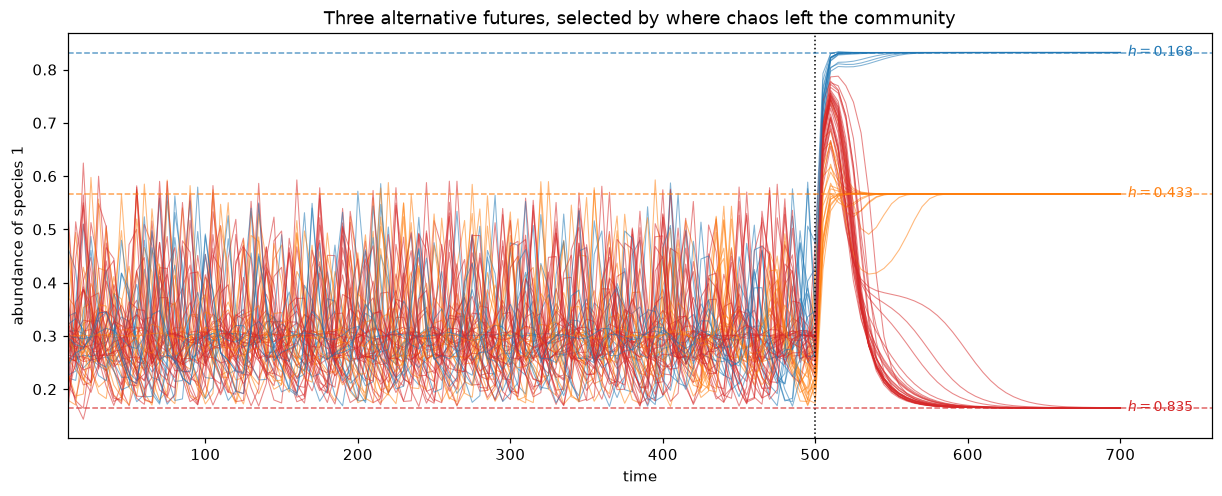

In [17]:
truth3, t3 = info3["true_states"], info3["times"]
colours = ["tab:blue", "tab:orange", "tab:red"]

fig, ax = plt.subplots(figsize=(11, 4.4), constrained_layout=True)
for m in range(60):
    k = int(np.argmin(np.abs(lv3 - fate3[m])))
    ax.plot(t3, truth3[m, :, 0], color=colours[k], lw=0.7, alpha=0.55)
ax.axvline(500.0, color="k", lw=1.0, ls=":")
for k, l in enumerate(lv3):
    ax.axhline(1 - l, color=colours[k], lw=1.0, ls="--", alpha=0.7)
    ax.annotate(f"$h={l:.3f}$", xy=(705, 1 - l), color=colours[k], fontsize=9, va="center")
ax.set_xlim(t3[0], 760)
ax.set_xlabel("time"); ax.set_ylabel("abundance of species 1")
ax.set_title("Three alternative futures, selected by where chaos left the community")
fig.savefig("eco_fig_three.png", dpi=140, bbox_inches="tight")

The interesting question is now graded rather than binary: not *can the good outcome still be secured*, but **how good an outcome is still affordable**. The control effect function answers it directly — it returns the best reachable level, and the sublevel controllability value gives the price of each tier separately.

median cost to secure each tier (0 = already assured):
  window      h<=0.168   h<=0.433   h<=0.835   
  [  0,200)     0.0047      0.0000      0.0000   
  [200,400)     0.0078      0.0000      0.0000   
  [400,500)     0.0193      0.0000      0.0000   
  [500,560)     0.1772      0.0000      0.0000   
  [560,700)     0.4594      0.0000      0.0000   

Mean best-reachable h (smaller is better):



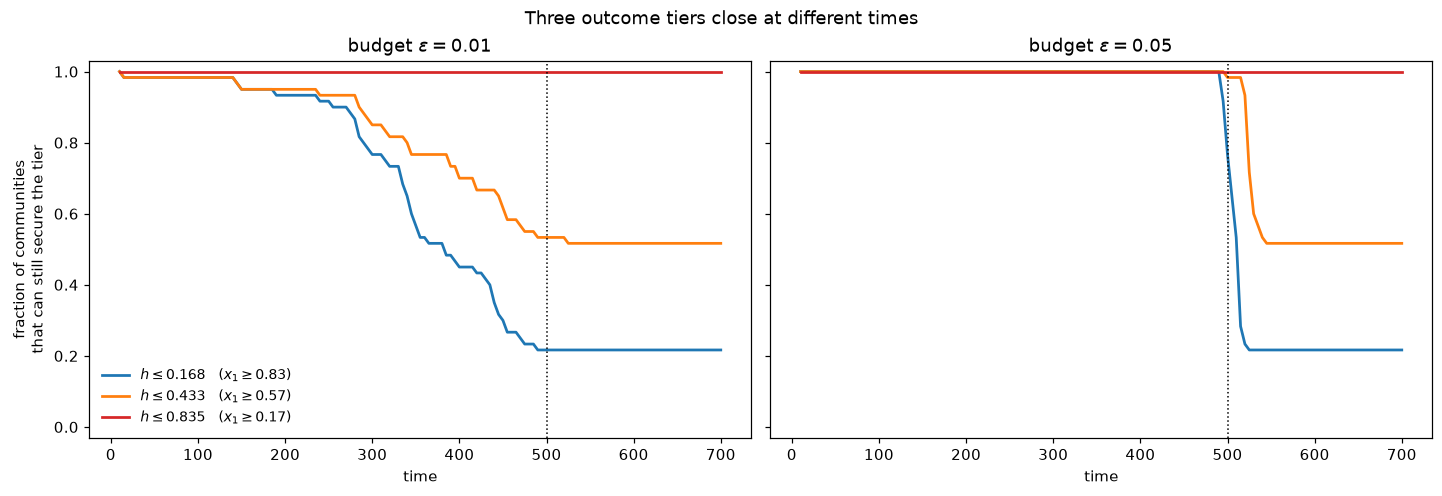

,0-200,200-400,400-500,500-560,560-700
eps,,,,,
0.000,0.5699,0.5699,0.5699,0.5699,0.5699
0.005,0.3757,0.4698,0.5472,0.5677,0.5699
0.010,0.1852,0.2880,0.4972,0.5671,0.5699
0.050,0.1680,0.1680,0.1691,0.4512,0.5699
0.200,0.1680,0.1680,0.1680,0.3192,0.5697


In [18]:
t_ = adata3.obs["t"].to_numpy()
cost3 = prob3.control_cost()           # one column per level, ascending
t_grid = np.unique(t_)

# For a fixed budget, what fraction of communities can still secure each tier?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True, sharey=True)
for ax_, eps in zip(axes, (0.01, 0.05)):
    for k, l in enumerate(lv3):
        frac = [np.mean(cost3[t_ == tt, k] <= eps) for tt in t_grid]
        ax_.plot(t_grid, frac, color=colours[k], lw=1.8,
                 label=rf"$h \leq {l:.3f}$   ($x_1 \geq {1-l:.2f}$)")
    ax_.axvline(500.0, color="k", lw=1.0, ls=":")
    ax_.set_xlabel("time"); ax_.set_title(rf"budget $\varepsilon = {eps:g}$")
    ax_.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("fraction of communities\nthat can still secure the tier")
axes[0].legend(frameon=False, loc="lower left", fontsize=9)
fig.suptitle("Three outcome tiers close at different times")
fig.savefig("eco_fig_three_cost.png", dpi=140, bbox_inches="tight")

windows3 = [(0, 200), (200, 400), (400, 500), (500, 560), (560, 700)]
print("median cost to secure each tier (0 = already assured):")
print("  window      " + "".join(f"h<={l:.3f}   " for l in lv3))
for lo, hi in windows3:
    m = (t_ >= lo) & (t_ < hi)
    print(f"  [{lo:3d},{hi:3d})  " + "".join(f"{np.median(cost3[m, k]):9.4f}   "
                                             for k in range(len(lv3))))

tab = []
for eps in (0.0, 0.005, 0.01, 0.05, 0.2):
    eff = prob3.control_effect(eps)
    row = {"eps": eps}
    for lo, hi in windows3:
        m = (t_ >= lo) & (t_ < hi)
        row[f"{lo}-{hi}"] = eff[m].mean()
    tab.append(row)
print("\nMean best-reachable h (smaller is better):\n")
pd.DataFrame(tab).set_index("eps").round(4)

Two things to read off. In the left panel the tiers **close at different times**: with a modest budget of $0.01$ the top tier ($x_1 \ge 0.83$) starts slipping away around $t = 200$ and is gone from four fifths of communities by the shift, while the middle tier ($x_1 \ge 0.57$) survives longer and the bottom tier costs nothing from anywhere. A stricter target never costs less and always closes first — Lemma 2.5 made visible.

In the right panel a five-times larger budget holds every tier open right up to the disturbance, then loses them within about 40 time units of it. Increasing the budget does not extend the window indefinitely; it moves the collapse later and makes it sharper.

The table says the same thing in terms of the effect function. At $\varepsilon = 0.01$ the mean best-reachable outcome early in the chaotic phase is $0.185$ — close to the best level $0.168$ — and by the post-shift phase it has returned to the no-control value $0.570$. The budget that was nearly decisive at $t = 100$ does nothing at $t = 600$.

This is the practically useful form of the result. A manager rarely faces "save it or lose it"; they face a menu of outcomes at different prices, with every price rising as the window closes, and the most desirable option becoming unaffordable first.

## 9. The whole picture: every state, every budget, every norm

The curves so far aggregated over states. `plot_effect_heatmap` shows the effect function itself without aggregating: one cell per (trajectory, time), coloured by the best outcome still reachable from that state, with one panel per $(p, \varepsilon)$ pair.

Sorting the rows by terminal outcome is what makes this readable. The uncontrolled panel then resolves into solid bands — by construction, since with no control each trajectory's fate is fixed from the start — so **any other colour appearing inside a band is a state whose fate control can still change**.

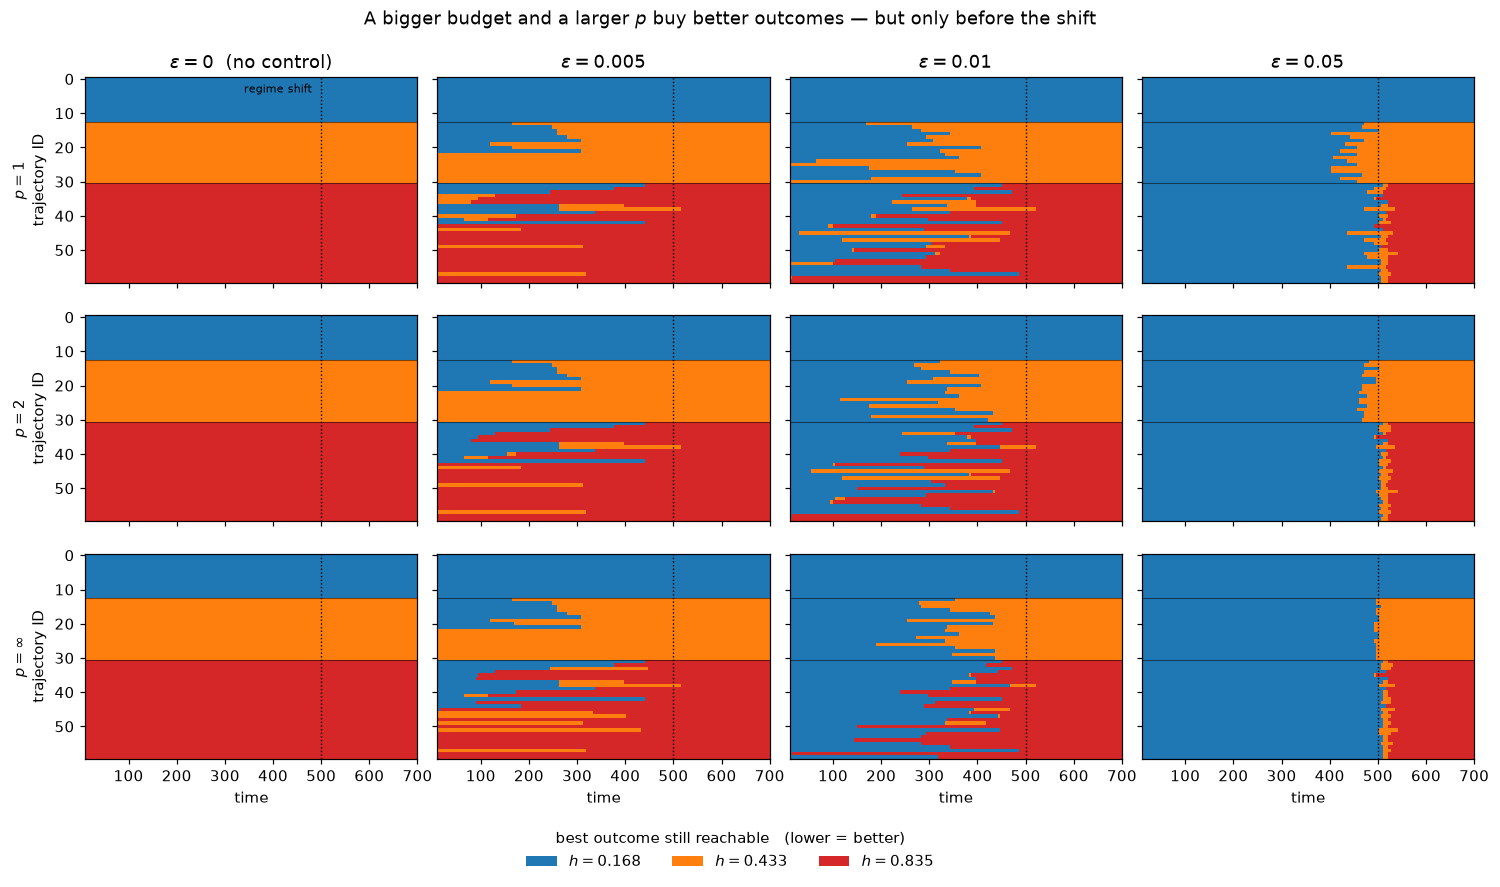

In [19]:
fig, axes = ec.plot_effect_heatmap(
    adata3, prob3,
    ps=(1.0, 2.0, np.inf),
    epsilons=(0.0, 0.005, 0.01, 0.05),
    colors=colours,                      # same outcome colours as the figures above
    title=r"A bigger budget and a larger $p$ buy better outcomes"
          " — but only before the shift",
)
axes[0, 0].annotate("regime shift", xy=(500, 3), xytext=(480, 3),
                    ha="right", va="center", fontsize=7)
fig.savefig("eco_fig_effect_heatmap.png", dpi=160)

The left column ($\varepsilon = 0$) is the reference: three clean bands, identical across the three rows because with no control the norm plays no role. Moving right, the upper colours invade the lower bands — most visibly the red band, where blue and orange cells mark communities that would have ended badly but can still be steered to a better outcome. The invasion always starts at early times and retreats as the dotted line approaches.

Moving down, the invaded region grows slightly at fixed budget: $p = \infty$ caps each individual input, so the same nominal budget may be spent at every census, whereas $p = 1$ caps the total.

In [20]:
n_mem = adata3.obs["seq_id"].nunique()
T = np.tile(info3["times"], (n_mem, 1))
best = lv3[0]

print("fraction of states from which the BEST outcome is still reachable\n")
print("        " + "".join(f"eps={e:<8g}" for e in (0.0, 0.005, 0.01, 0.05)))
for p in (1.0, 2.0, np.inf):
    pr = prob3 if prob3.p == p else prob3.with_p(p)
    grids = {e: pr.control_effect(e).reshape(n_mem, -1) for e in (0.0, 0.005, 0.01, 0.05)}
    pre = [np.mean(np.isclose(g[T < 500.0], best)) for g in grids.values()]
    post = [np.mean(np.isclose(g[T > 550.0], best)) for g in grids.values()]
    lab = "p=inf" if np.isinf(p) else f"p={p:g}"
    print(f"  {lab:<6} before " + "".join(f"{v:<12.2f}" for v in pre))
    print(f"  {'':<6} after  " + "".join(f"{v:<12.2f}" for v in post))

g1 = prob3.with_p(1.0).control_effect(0.01)
gi = prob3.with_p(np.inf).control_effect(0.01)
gain = (gi < g1 - 1e-12).reshape(n_mem, -1)
print(f"\nat eps=0.01, p=inf beats p=1 at {gain.mean():.1%} of states:")
print(f"   before the shift {np.mean(gain[T < 500.0]):.1%},"
      f"   after {np.mean(gain[T > 500.0]):.1%}")

fraction of states from which the BEST outcome is still reachable

        eps=0       eps=0.005   eps=0.01    eps=0.05    
  p=1    before 0.22        0.37        0.61        0.96        
         after  0.22        0.22        0.22        0.22        
  p=2    before 0.22        0.38        0.68        0.99        
         after  0.22        0.22        0.22        0.22        
  p=inf  before 0.22        0.39        0.75        1.00        
         after  0.22        0.22        0.22        0.22        

at eps=0.01, p=inf beats p=1 at 10.1% of states:
   before the shift 14.3%,   after 0.0%


Two things this view shows that the aggregated curves could not.

**Leverage is unevenly distributed across trajectories.** Within the red band at $\varepsilon = 0.01$, some rows stay blue until $t \approx 450$ while others have set to red by $t \approx 200$. Communities headed for the same outcome can differ greatly in how long they remain steerable — an individual-level spread that any summary statistic averages away. For a monitoring programme this is the actionable part: it is not the outcome that tells you where to spend, it is the width of the coloured region in that row.

**The choice of norm only matters before the shift.** At $\varepsilon = 0.01$, $p = \infty$ gives a strictly better reachable outcome than $p = 1$ at about a tenth of all states, and essentially all of them lie before $t = 500$. No accounting of effort helps once the window has closed.

The panels are also a visual check on the theory: colours can only improve to the right (Lemma 3.7) and, at fixed $\varepsilon \ge 0$, downward (Lemma 3.9), which is exactly the monotonicity that makes the three-parameter family of §7 a filtration.